In [1]:
try:
    import pandas as pd
    import json
    import statsmodels.api as sm
    from statsmodels.regression.linear_model import OLS
    import matplotlib.pyplot as plt
    import numpy as np
except ImportError:
    !pip install pandas
    !pip install statsmodels
    !pip install matplotlib.pyplot
    !pip install numpy
    import numpy as np
    import matplotlib as plt
    import pandas as pd
    import statsmodels.api as sm
    from statsmodels.regression.linear_model import OLS

In [2]:
# Убрать ограничение на количество отображаемых строк
pd.set_option('display.max_rows', 200)  # None означает "без ограничений"
pd.set_option('display.max_columns', 200)  # для столбцов

# Если нужно вернуть настройки по умолчанию:
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')

In [3]:
def prepare_data(path_to_table):
    table = pd.read_excel(path_to_table)   
    return table
    
LOAD_TABLE_PATH = 'C:\\Users\\Никита Комиссаров\\Yandex.Disk\\учеба\\прогноз\\load_data.xlsx'
AHT_TABLE_PATH = 'C:\\Users\\Никита Комиссаров\\Yandex.Disk\\учеба\\прогноз\\load_data_aht.xlsx'

load_table = prepare_data(LOAD_TABLE_PATH)
aht_table = prepare_data(AHT_TABLE_PATH)


***Модуль подготовки исторических данных***

In [4]:
#Подготавлияваем данные, делаем центральную таблицу, из которой будем тянуть данные, считать общие параметры на группы

load_table['last_date'], load_table['first_date'] = load_table.groupby('queueId')['dateTime_scaled'].transform('max'),  load_table.groupby('queueId')['dateTime_scaled'].transform('min')
load_table['prev_month_date'] = load_table['last_date'] -  pd.DateOffset(months=1)
load_table['date'] = pd.to_datetime(load_table['dateTime_scaled'].dt.date)
load_table['day'] = load_table['date'].dt.dayofweek
load_table['hour'] = load_table['dateTime_scaled'].dt.hour
load_table['interval'] = (load_table['dateTime_scaled'].dt.minute)//15+1

#Интересный способ вместо merge
load_table['aht'] = load_table.apply(
    lambda row: 
        aht_table.loc[
            (aht_table['dateTime_scaled'].dt.day == row['dateTime_scaled'].day) &
            (aht_table['queueId'] == row['queueId']),
            'aht'
        ].values[0] 
        if not aht_table[
            (aht_table['dateTime_scaled'].dt.day == row['dateTime_scaled'].day) &
            (aht_table['queueId'] == row['queueId'])
        ].empty 
        else None,
    axis=1
) 

display(load_table)

,dateTime_scaled,queueId,globalId,is_automatization,last_date,first_date,prev_month_date,date,day,hour,interval,aht
0,2025-07-23 23:45:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760
1,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760
2,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760
3,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760
4,2025-07-23 23:45:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760
...,...,...,...,...,...,...,...,...,...,...,...,...
20419,2025-06-17 00:00:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775
20420,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775
20421,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775
20422,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775


In [5]:
# Делаем "панель управления", по которой можно будет в дальнейшем добавлять очереди, группировать по нужным командам и тд.

data = {
    "queues": [
        {
            "queue_id": 999,
            "team": "Support Team A",
            "metrics": [{
                "aht": 300,
                "count": 150,
                "bottom": 0.25,
                "ceiling": 0.75,
                "automatization_rate": 0.6,
                "aggregation": "1",
                "first_date": "2025-06-01",
                "last_date": "2025-06-30"
            }]
        },
        {
            "queue_id": 106797,
            "team": "Support Team B",
            "metrics": [{
                "aht": 350,
                "count": 120,
                "bottom": 0.25,
                "ceiling": 0.75,
                "automatization_rate": 0.5,
                "aggregation": "2",
                "first_date": "2025-06-01",
                "last_date": "2025-06-30"
            }]
        }
    ]
}


control_table = pd.json_normalize(data['queues'], 
                   record_path=['metrics'], 
                   meta=['queue_id', 'team'])

# Делаем список с праздниками или особыми днями, для которых нужен отдельный расчет сезонности
event_dates = ['2025-06-30', '2025-06-31']

display(control_table)

,aht,count,bottom,ceiling,automatization_rate,aggregation,first_date,last_date,queue_id,team
0,300,150,0.25,0.75,0.6,1,2025-06-01,2025-06-30,999,Support Team A
1,350,120,0.25,0.75,0.5,2,2025-06-01,2025-06-30,106797,Support Team B


In [6]:
#Подготавлияваем данные, делаем центральную таблицу, из которой будем тянуть данные, считать общие параметры на группы

central_table = load_table[(load_table['dateTime_scaled'] > load_table['prev_month_date'])
                          ].groupby('queueId').agg(month_id_count=('globalId', 'sum'),
                        month_aht_avg=('aht', 'mean'),                         
                         month_automatization_count=('is_automatization', 'sum'),
                         last_date=('last_date', 'max'),
                         first_date=('first_date', 'min')
                        )

central_table = central_table.merge(control_table[['ceiling', 'bottom', 'automatization_rate', 'queue_id', 'team']], left_on='queueId', right_on='queue_id', how='right')

load_table = load_table.merge(central_table[['queue_id', 'team']], left_on='queueId', right_on='queue_id', how='left').drop('queue_id', axis=1)

display(central_table, load_table)

,month_id_count,month_aht_avg,month_automatization_count,last_date,first_date,ceiling,bottom,automatization_rate,queue_id,team
0,56141.0,757.879476,0.0,2025-07-23 23:45:00,2025-06-17,0.75,0.25,0.6,999,Support Team A
1,NaN,NaN,NaN,NaT,NaT,0.75,0.25,0.5,106797,Support Team B


,dateTime_scaled,queueId,globalId,is_automatization,last_date,first_date,prev_month_date,date,day,hour,interval,aht,team
0,2025-07-23 23:45:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
1,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
2,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
3,2025-07-23 23:45:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
4,2025-07-23 23:45:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-07-23,2,23,4,571.18760,Support Team A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20419,2025-06-17 00:00:00,999,2,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775,Support Team A
20420,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775,Support Team A
20421,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775,Support Team A
20422,2025-06-17 00:00:00,999,1,False,2025-07-23 23:45:00,2025-06-17,2025-06-23 23:45:00,2025-06-17,1,0,1,1802.71775,Support Team A


In [7]:
def prepare_historical_sample(load_table, team):
    historical_sample = pd.DataFrame(load_table[load_table['team'] == team].groupby('date')['globalId'].sum()).sort_values(by='date', ascending=True)
    historical_sample.reset_index(drop=False, inplace=True)
    historical_sample['number'] = [x+1 for x in range(len(historical_sample.index))]

    historical_sample['day'] = historical_sample['date'].dt.dayofweek
    
    return historical_sample

def create_reg_params(historical_sample):
    X = historical_sample['number']
    Y = historical_sample['globalId']
    X = sm.add_constant(X, prepend=False)

    model = OLS(Y, X)
    
    return model

team_a = 'Support Team A'    
historical_sample_a = prepare_historical_sample(load_table, 'Support Team A')
model_a = create_reg_params(historical_sample_a)

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


***Модуль прогнозирования по дням линейной регрессией***

In [8]:
def create_prediction_sample(historical_sample, model):
    # Cоздаем фрейм, который в котором будем строить базовый прогноз без сезонности по дням
    
    # Расширяем список на нужный нам размер, здесь 1000, и нумеруем (number), чтобы использовать ее как независимую переменную
    prediction_sample = historical_sample.reindex(range(1000))
    prediction_sample['number'] = [x+1 for x in range(len(prediction_sample.index))]

    # Определяем начало и конец, где начало (start_date) - максимальная дата в исторической Серии +1, 
    # конец (end_date) - на ваше усмотрение, но чтобы хватило размаха (1000) из прошлой итерации
    # Определяем начальный и конечные индексы, где начальный (start_index) равен индексу максимальной исторической дате +1,
    # конечный (end_index) - максимальный индекс в исторической Серии (999 в нашем случае). 
    start_date = max(prediction_sample['date']+pd.Timedelta(days=1))
    start_index = prediction_sample[prediction_sample['date']==max(prediction_sample['date'])].index[0]+1
    end_date = '2026-01-01'
    end_index = max(prediction_sample.index)
    
    # Делаем фрейм с ранжированием дат в будущем, чтобы смёрджить его с историческим фреймом, 
    # смещаем индексы под исторический фрейм
    date_range = pd.DataFrame(pd.date_range(start=start_date, end=end_date))
    date_range.index = range(start_index, len(date_range)+start_index)
    
    # Объединяем фрейм с будущими датами и исторический фреймы
    prediction_sample = prediction_sample.merge(date_range, left_index=True, right_index=True, how='outer')
    display(prediction_sample)
    prediction_sample['date'] = prediction_sample.apply(lambda x: x[0] if pd.isna(x['date']) else x['date'], axis=1)
    prediction_sample = prediction_sample.drop(columns=[0])
    
    # Пронумеруем все дни, чтобы потом рассчитать для каждого дня сезонность
    prediction_sample['day'] = prediction_sample['date'].dt.dayofweek
    

    # Рассчитываем коэффициенты
    # Уравнение л. регресии: b + ax
    # b - свободный член
    # a - отвечает за наклон
    
    res = model.fit()
    a_coef = res.params[0]
    b_coef = res.params[1]  
    
    # Строим линию тренда, вместо 0 можно использовать a_coef, если вы хотите учитывать наклон.
    prediction_sample['trend'] = b_coef +  (0 * prediction_sample['number'])
    
    return prediction_sample 

def find_day_median_difference(prediction_sample, max_date_historical, event_dates):
    # Рассчитываем медианное значение разницы между фактом и трендом для каждого дня в течение последних 96 дней
    prediction_sample = prediction_sample.copy()
    
    median_threshold = max_date_historical - pd.Timedelta(days=96)
    prediction_sample['day_difference']  = prediction_sample['globalId'] - prediction_sample['trend']
    days_median_difference = prediction_sample[(prediction_sample['date'] >= median_threshold) & (~prediction_sample['date'].isin(event_dates))].groupby('day')['day_difference'].median()
    
    return days_median_difference

def find_event_median_difference(prediction_sample, max_date_historical, event_dates):
    # Рассчитываем медианное значение разницы между фактом и трендом для events последних 96 дней
    prediction_sample = prediction_sample.copy()
    
    median_threshold = max_date_historical - pd.Timedelta(days=96)
    prediction_sample['event_difference'] = prediction_sample[prediction_sample['date'].isin(event_dates)]['globalId'] - prediction_sample['trend']
    event_median_difference = prediction_sample[(prediction_sample['date'] >= median_threshold) & (prediction_sample['date'].isin(event_dates))].groupby('date')['event_difference'].median()
    
    return event_median_difference
    
def create_prognosis(prediction_sample, days_median_difference, events_median_difference, event_dates):
    # Рассчитываем сезонность для каждого дня недели
    prediction_sample['events_median_difference'] = prediction_sample_a[prediction_sample['date'].isin(event_dates)]['date'].map(events_median_difference_a)
    prediction_sample['days_median_difference'] = prediction_sample_a[~prediction_sample['date'].isin(event_dates)]['day'].map(days_median_difference_a)
    
    # Строим прогноз
    prediction_sample['prognosis'] = prediction_sample.apply(lambda row: row['trend'] + row['days_median_difference'] 
                                                             if pd.isna(row['events_median_difference']) 
                                                             else row['trend'] + row['events_median_difference'], axis=1)
    
    return prediction_sample
    

prediction_sample_a = create_prediction_sample(historical_sample_a, model_a)
days_median_difference_a = find_day_median_difference(prediction_sample_a, historical_sample_a['date'].max(), event_dates)
events_median_difference_a = find_event_median_difference(prediction_sample_a, historical_sample_a['date'].max(), event_dates)
prediction_sample_a = create_prognosis(prediction_sample_a, days_median_difference_a, events_median_difference_a, event_dates)

display(prediction_sample_a.head(50))

,date,globalId,number,day,0
0,2025-06-17,2184.0,1,1.0,NaT
1,2025-06-18,1944.0,2,2.0,NaT
2,2025-06-19,1890.0,3,3.0,NaT
3,2025-06-20,1860.0,4,4.0,NaT
4,2025-06-21,1259.0,5,5.0,NaT
...,...,...,...,...,...
995,NaT,NaN,996,NaN,NaT
996,NaT,NaN,997,NaN,NaT
997,NaT,NaN,998,NaN,NaT
998,NaT,NaN,999,NaN,NaT


,date,globalId,number,day,trend,events_median_difference,days_median_difference,prognosis
0,2025-06-17,2184.0,1,1.0,1808.806306,NaN,329.193694,2138.0
1,2025-06-18,1944.0,2,2.0,1808.806306,NaN,231.693694,2040.5
2,2025-06-19,1890.0,3,3.0,1808.806306,NaN,241.193694,2050.0
3,2025-06-20,1860.0,4,4.0,1808.806306,NaN,89.193694,1898.0
4,2025-06-21,1259.0,5,5.0,1808.806306,NaN,-598.806306,1210.0
5,2025-06-22,1255.0,6,6.0,1808.806306,NaN,-570.806306,1238.0
6,2025-06-23,2223.0,7,0.0,1808.806306,NaN,414.193694,2223.0
7,2025-06-24,2063.0,8,1.0,1808.806306,NaN,329.193694,2138.0
8,2025-06-25,1911.0,9,2.0,1808.806306,NaN,231.693694,2040.5
9,2025-06-26,2050.0,10,3.0,1808.806306,NaN,241.193694,2050.0


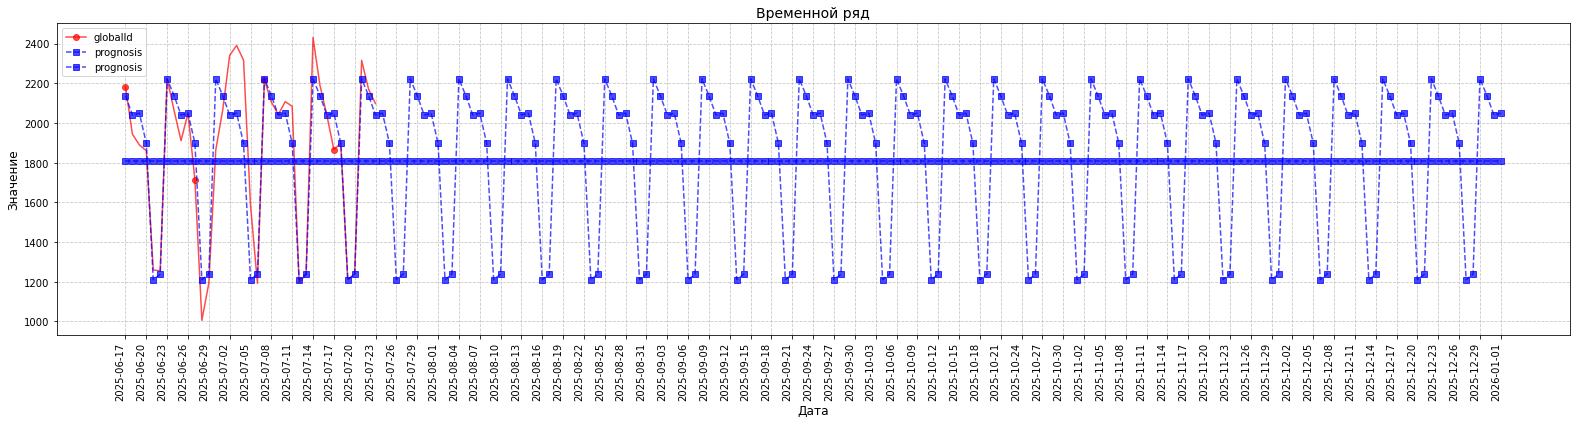

In [9]:
import numpy as np

def draw_chart(timeline, historical, prognosis):
    # Создаем график
    plt.figure(figsize=(22, 6))

    # Разделяем построение линий для каждого значения
    # Строим линию для globalId
    plt.plot(prediction_sample_a['date'], 
             prediction_sample_a['globalId'], 
             linestyle='-', 
             marker='o',
             markevery=10,
             color='red',  # Цвет для globalId
             alpha=0.7,
             label='globalId')

    # Строим линию для prognosis
    plt.plot(prediction_sample_a['date'], 
             prediction_sample_a['prognosis'], 
             linestyle='--',  # Другой стиль линии
             marker='s', 
             # Другой маркер
             color='blue',    # Цвет для prognosis
             alpha=0.7,
             label='prognosis')
    
        # Строим линию для trend
    plt.plot(prediction_sample_a['date'], 
             prediction_sample_a['trend'], 
             linestyle='--',  # Другой стиль линии
             marker='s', 
             # Другой маркер
             color='blue',    # Цвет для prognosis
             alpha=0.7,
             label='prognosis')

    plt.xticks(
        ticks=np.arange(
            prediction_sample_a['date'].min(), 
            prediction_sample_a['date'].max() + pd.Timedelta(days=1), 
            pd.Timedelta(days=3)
        ),
        rotation=45,
        ha='right'
    )

    # Настройка осей
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.title('Временной ряд', fontsize=14)

    # Поворот меток по оси X
    plt.xticks(rotation=90, ha='right')

    # Добавляем сетку
    plt.grid(True, linestyle='--', alpha=0.7)

    # Добавляем легенду
    plt.legend(loc='upper left')

    # Отображаем график
    plt.tight_layout()
    plt.show()
    
    display()

draw_chart(prediction_sample_a['date'], prediction_sample_a['globalId'], prediction_sample_a['prognosis'])

***Модуль интервально-дневных коэффициентов***

In [10]:
# В этом блоке собираем данные по нагрузки в разрезе интервалов и перерабатываем выбросы

percentile_h = 0.75
percentile_l = 0.25

# Cобираем сводную таблицу из исторических данных, чтобы сгруппировать нагрузку по датам и дням недели.
def create_interval_pivot_table(load_table, team):
    # Готовим данные
    statistical_table = load_table[(load_table['team'] == team) &
                              (load_table['dateTime_scaled'] >=
                               (load_table['dateTime_scaled'].max() - pd.Timedelta(days=96)))][
        ['dateTime_scaled', 'globalId', 'day', 'hour', 'interval', 'date']]


# Создаем сводную таблицу с исторической нагрузкой по каждому интервалу
    pivot_table_historical = statistical_table.pivot_table(
        values='globalId',
        index=['hour', 'interval'],
        columns=['day', 'date'],
        aggfunc='median',
        fill_value=0
    )

    return pivot_table_historical

# Пересчитываем исторические данные, чтобы они были в рамках percentile_h, percentile_l. Если нет - замена на медиану
def recalculate_statistics_table(pivot_table_historical, percentile_h, percentile_l): 
    
    # Копируем исходную таблицу
    pivot_table_processed = pivot_table_historical.copy()

    # Проходим по каждой строке
    for idx, row in pivot_table_processed.iterrows():
        # Проходим по каждому столбцу (день недели)
        for col in pivot_table_processed.columns.levels[0]:
            # Получаем все значения для текущего дня
            values = row[col].values
            # Вычисляем процентили и медиану
            pctl_h = np.percentile(values, percentile_h)
            pctl_l = np.percentile(values, percentile_l)
            median_val = np.median(values)

        # Заменяем все, что больше указанных выше процентилей путем замены на медиану:
            pivot_table_processed.loc[idx, (col, slice(None))] = np.where(
                (values > pctl_h) | (values < pctl_l),
                median_val,
                values
            )
    
    pivot_table_processed.to_excel('processed.xlsx', sheet_name='processed')
    
    return pivot_table_processed

pivot_table_historical_a = create_interval_pivot_table(load_table, team_a)
pivot_table_historical_a.to_excel('historical.xlsx', sheet_name='historical')

recalculated_interval_table_a = recalculate_statistics_table(pivot_table_historical_a, percentile_h, percentile_l)
pivot_table_historical_a.to_excel('recalculated_historical.xlsx', sheet_name='historical')

In [11]:
# Найдем суммарную нагрузку для каждой даты, чтобы потом рассчитать % (коэффициент) на каждый интервал
def find_day_sum(recalculated_interval_table):
    date_sum = dict()
    day_sum_table = recalculated_interval_table.copy()
    for col in day_sum_table.columns:
        date_sum[col] = day_sum_table[col].values.sum()
        
    return date_sum

# Рассчитаем коэффициент каждого интервала путем его деления на сумму дня
def define_coeff(date_sum_tabel, recalculated_interval_table):
    coeff_interval_table = recalculated_interval_table.copy()
    for col in recalculated_interval_table.columns:
        coeff_interval_table[col] = recalculated_interval_table[col]/date_sum_tabel[col]
            
    coeff_interval_table.to_excel('coefs.xlsx', sheet_name='coefs')  
    
    return coeff_interval_table

# Возьмем медиану диапазона дат, которые относятся ко дню недели, 
# чтобы рассчитать коэфициенты уже не по дням и датам, а только по дням. 
def create_day_coeff_table(coeff_table):
    coeff_table = coeff_table.copy()
    day_coeff_table = pd.DataFrame(np.nan, index=range(96), columns=np.arange(7))
    for col in coeff_table.columns.levels[0]:
        row_number=0
        for row_idx in coeff_table.index:
            day_coeff_table.loc[row_number, col] = np.median(coeff_table.loc[row_idx, col].values)
            row_number+=1
            
    return day_coeff_table

#Рассчитываем итоговую таблицу коэффициентов для всей недели
def create_final_day_coeff_table(day_coeff_table):
    day_coeff_sum_table = find_day_sum(day_coeff_table)
    day_coeff_sum_table = day_coeff_sum_table.copy()
    final_day_coeff_table = pd.DataFrame(np.nan, index=range(96), columns=np.arange(7))
    for col in day_coeff_table.columns:
        final_day_coeff_table[col] = day_coeff_table[col]/day_coeff_sum_table[col]
                 
    return final_day_coeff_table
    
               
date_sum_table_a = find_day_sum(recalculated_interval_table_a)    
coeff_table_a = define_coeff(date_sum_table_a, recalculated_interval_table_a)
day_coeff_table_a = create_day_coeff_table(coeff_table_a)
final_day_coeff_table_a = create_final_day_coeff_table(day_coeff_table_a)

final_day_coeff_table_a.to_excel('final_coeffs.xlsx', sheet_name='coeffs')

**Модуль построения интервального прогноза**

In [12]:
start_date_a, end_date_a = "01.01.2025", "01.01.2026"

# Рассчитываем количество обращений на каждый интервал по собранным ранее коэффициентам и спрогнозированной нагрузке на день
def create_final_day_dist_table(start_date, end_date, final_day_coeff_table, prediction_sample):
    date_range_final = pd.DataFrame(pd.date_range(start=start_date, end=end_date), columns=['date'])
    date_range_final['day'] = date_range_final['date'].dt.dayofweek
    final_day_dist_table = date_range_final.transpose()
    final_day_dist_table = final_day_dist_table.reindex(index=np.array(range(96)), columns=pd.MultiIndex.from_arrays(date_range_final[['date', 'day']].values.transpose()))
    
    for col in final_day_dist_table.columns:
        for row_index in final_day_dist_table[col].index:
            if not prediction_sample_a['prognosis'][prediction_sample_a['date'] == col[0]].empty:
                final_day_dist_table[col] = (prediction_sample_a['prognosis'][prediction_sample_a['date'] == col[0]].values[0])*final_day_coeff_table[col[1]]
                final_day_dist_table = final_day_dist_table.fillna(0)
    return final_day_dist_table

final_day_dist_table = create_final_day_dist_table(start_date_a, end_date_a, final_day_coeff_table_a, prediction_sample_a)

# выгружаем финал в Эксель
final_day_dist_table.to_excel('final.xlsx', sheet_name='final')